Importing & Inspecting Pickle File


In [ ]:
import numpy as np
import matplotlib.pyplot as plt # generate plots
import seaborn as sns # create complex plots
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, precision_recall_curve
)
from sklearn.model_selection import learning_curve
import pickle

import warnings
# Suppress all warnings
warnings.filterwarnings("ignore")

# Load the saved TF-IDF + split data
with open('tfidf_split.pkl', 'rb') as f:
    X_train, X_test, y_train, y_test, tfidf, numeric_cols = pickle.load(f)


- AUC-ROC: plot against TP & FP (how many false alarms to accept to get true "Yes" cases)
- AUC - closer to 1, the model is better at separating the 2





Tuned Base Model to show the best performance possible, over the hyperparameter tuned version

Function for evaluate_model
- separate function for all to ensure consistency
- make the code for each model organized

In [ ]:
# Used across all models
def evaluate_model(model, X_train, y_train, X_test, y_test):

    # Detect label type (string vs numeric)
    unique_labels = set(y_test) # gets all unique values in target variable

    if unique_labels == {0, 1}: # 
        pos_label_metric = 1 # set positive as 1
        labels_cm = [0, 1] # order for matrix, negative then positive
    else:
        pos_label_metric = "yes"  # set positive as 1
        labels_cm = ["no", "yes"] # order for matrix, negative then positive

    # ---- Predictions ----
    y_pred = model.predict(X_test) # uses model prediction outcomes for the test data

    # ---- Metrics ----
    accuracy = accuracy_score(y_test, y_pred) # overall correctness percentage
    precision = precision_score(y_test, y_pred, pos_label=pos_label_metric)  # accuracy of positive predictions 
    recall = recall_score(y_test, y_pred, pos_label=pos_label_metric) # ability to find all TP
    f1 = f1_score(y_test, y_pred, pos_label=pos_label_metric) # mean of Precision & Recall

    print("\n=== MODEL PERFORMANCE ===")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    # ---- Confusion Matrix ----
    cm = confusion_matrix(y_test, y_pred, labels=labels_cm) # generate confusion matrix

    print("\nConfusion Matrix Breakdown:")
    tn, fp, fn, tp = cm.ravel() # unpacks the matrix into 4 individual numbers
    print("TN:", tn)
    print("FP:", fp)
    print("FN:", fn)
    print("TP:", tp)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels_cm, yticklabels=labels_cm)
    plt.title("Confusion Matrix")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

    # ---- ROC & PR Curves (if probability exists) ----
    y_scores = None # initialize variable to store scores

    # some models have a % probability
    # determine if the model supports probability prediction
    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)[:, 1] # Gets the probability of the positive class
    # if not, check if the model supports decision function
    elif hasattr(model, "decision_function"): # if model does not have probability
        y_scores = model.decision_function(X_test) # uses "distance score" (how far is it between the line, further is higher)

    # proceed when scores were found
    if y_scores is not None:

        # ROC (calculate true & false positive rates for the curve)
        fpr, tpr, _ = roc_curve(y_test, y_scores, pos_label=pos_label_metric)
        roc_auc = auc(fpr, tpr) # calculates the area Under the Curve (AUC) score

        plt.figure()
        plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
        plt.plot([0,1], [0,1], 'k--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve")
        plt.legend()
        plt.show()

        # Precision-Recall Curve 
        # calculate precision and recall values at different thresholds
        precision_vals, recall_vals, _ = precision_recall_curve(
            y_test, y_scores, pos_label=pos_label_metric
        )
        plt.figure()
        plt.plot(recall_vals, precision_vals)
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Precision-Recall Curve")
        plt.show()

    # ---- Learning Curve ----
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train, cv=5, # trains at 5-fold cross validation 
        train_sizes=np.linspace(0.1, 1.0, 5), # tests at 10%, 32%, 55%, 77%, and 100% of data
        scoring="accuracy" # uses accuracy to evaluate
    )

    plt.figure()
    plt.plot(train_sizes, train_scores.mean(axis=1), marker='o', label="Training")
    plt.plot(train_sizes, val_scores.mean(axis=1), marker='o', label="Validation")
    plt.xlabel("Training Samples")
    plt.ylabel("Accuracy")
    plt.title("Learning Curve")
    plt.legend()
    plt.show()


- TN + TP increase Accuracy
- FP lower Precision
- FN lower Recall

Logistic Regression


=== MODEL PERFORMANCE ===
Accuracy : 0.7676
Precision: 0.4795
Recall   : 0.7271
F1 Score : 0.5779

Confusion Matrix Breakdown:
TN: 2640
FP: 749
FN: 259
TP: 690


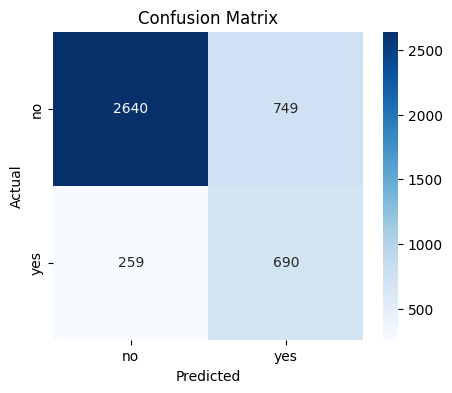

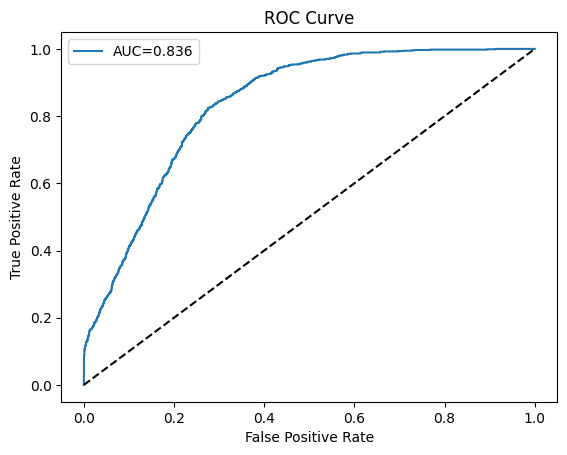

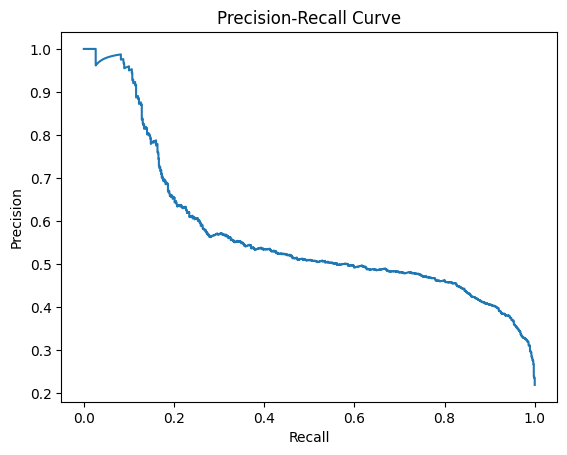

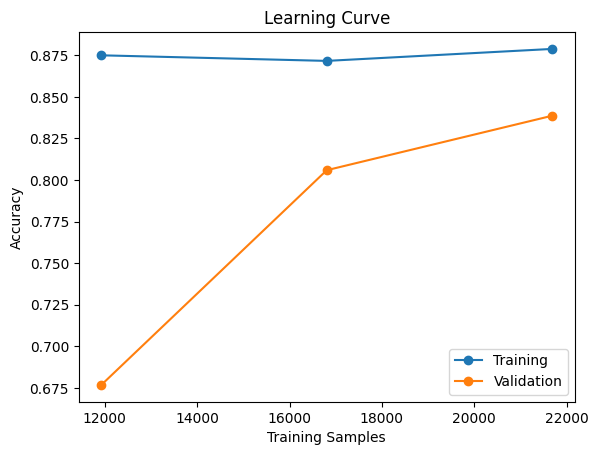

In [3]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    C= 1.0, # regularization strength               
    solver='liblinear', # optimization algorithm
    max_iter=3000, # iteration limit (prevent convergence errors)
    random_state=42 # ensuring results are reproducible
)

log_reg.fit(X_train, y_train)

evaluate_model(log_reg, X_train, y_train, X_test, y_test)

Logistic Regression Hyperparameter Tuning

Starting Logistic Regression Tuning...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

=== MODEL PERFORMANCE ===
Accuracy : 0.7561
Precision: 0.4662
Recall   : 0.7924
F1 Score : 0.5870

Confusion Matrix Breakdown:
TN: 2528
FP: 861
FN: 197
TP: 752


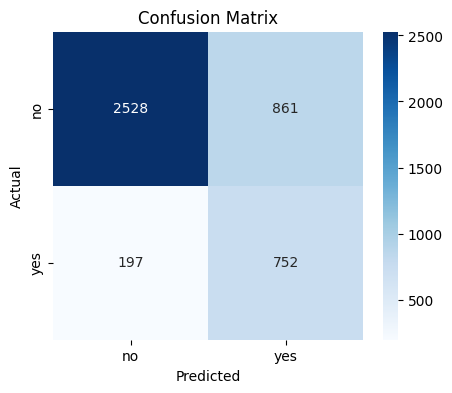

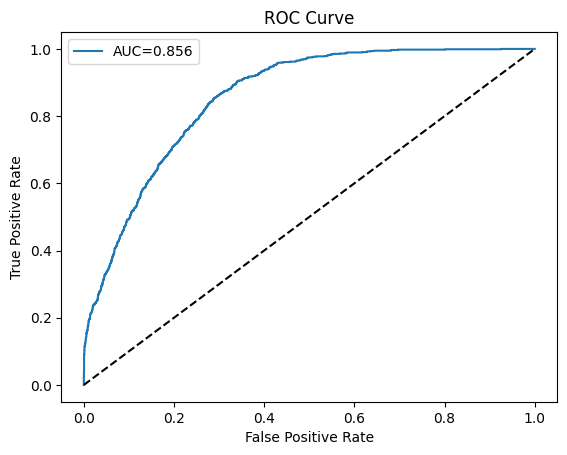

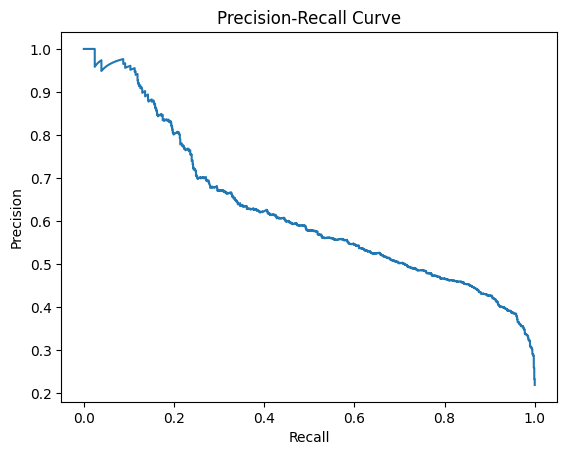

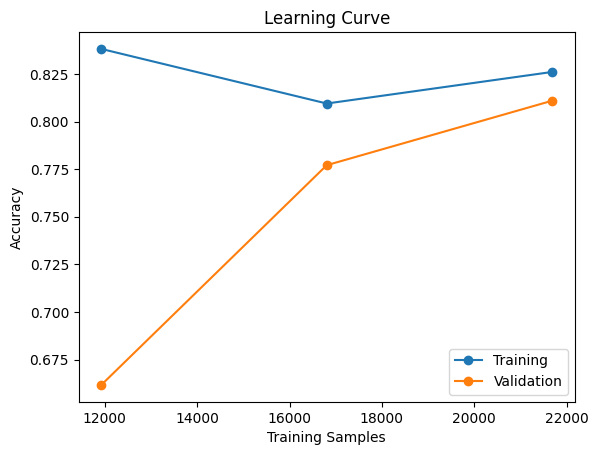

In [4]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Setup Model
log_reg = LogisticRegression(max_iter=3000, solver='liblinear', random_state=42)

# 2. Micro-Tuning Grid
# Testing small steps around 1.0, and trying L1 (delete noise) vs L2 (shrink noise)
param_grid = {
    'C': [0.8, 0.9, 1.0, 1.1, 1.2],
    'penalty': ['l1', 'l2']
}

# 3. Run Tuning
print("Starting Logistic Regression Tuning...")
grid_log = GridSearchCV(log_reg, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid_log.fit(X_train, y_train)

# 4. Evaluate Best Model
best_log = grid_log.best_estimator_
y_pred = best_log.predict(X_test)

best_log = grid_log.best_estimator_
evaluate_model(best_log, X_train, y_train, X_test, y_test)


RF (Random Forest Classifier)


=== MODEL PERFORMANCE ===
Accuracy : 0.7545
Precision: 0.4450
Recall   : 0.4942
F1 Score : 0.4683

Confusion Matrix Breakdown:
TN: 2804
FP: 585
FN: 480
TP: 469


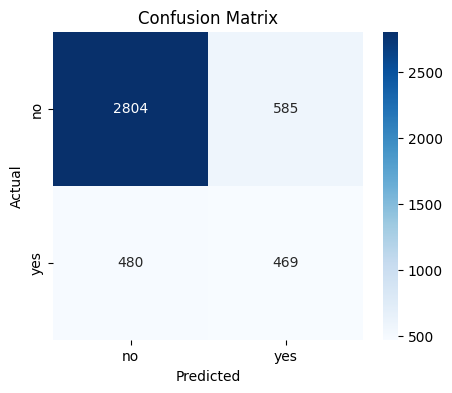

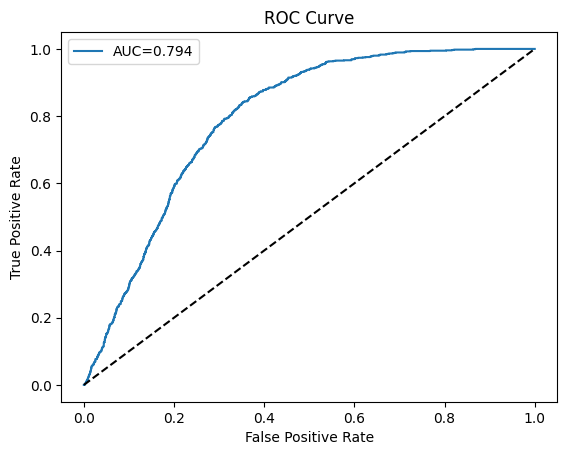

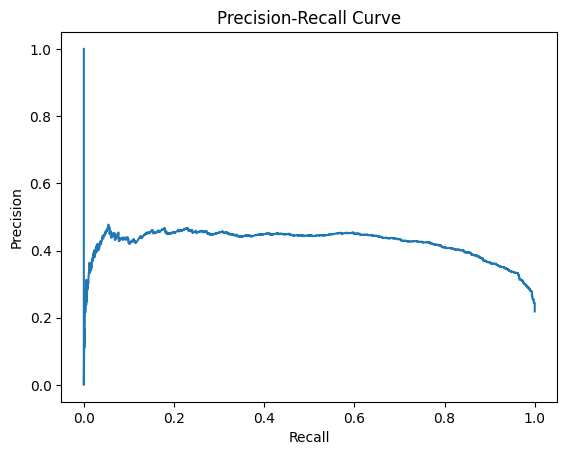

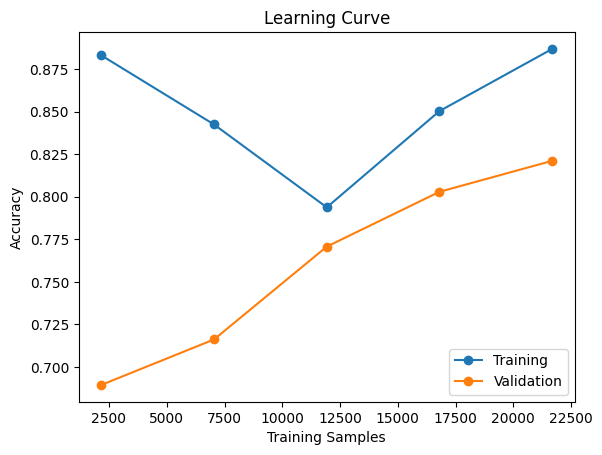

In [5]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100, # builds the number of trees 
    max_depth=20,  # limits to 20 levels deep to prevent memorizing         
    min_samples_split=10,  # looks for minimal samples to create new branch
    min_samples_leaf=4,  # minimum samples to form a leaf   
    class_weight='balanced',
    n_jobs=-1,              
    random_state=42
)

rf.fit(X_train, y_train)
evaluate_model(rf, X_train, y_train, X_test, y_test)

RF Hyperparameter Tuning

In [6]:
from sklearn.ensemble import RandomForestClassifier

# 1. Setup Model (n_jobs=-1 makes it faster)
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# 2. Conservative Grid (Prevents Overfitting)
param_grid = {
    'n_estimators': [100, 200],      # Enough trees to learn, but not too many
    'max_depth': [10, 20, 30],       # Limit depth to force general rules
    'min_samples_split': [5, 10]     # Require 5+ reviews to create a new branch
}

# 3. Run Tuning
print("Starting Random Forest Tuning...")
grid_rf = GridSearchCV(rf, param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=1)
grid_rf.fit(X_train, y_train)

# 4. Evaluate Best Model
best_rf = grid_rf.best_estimator_
y_pred = best_rf.predict(X_test)

print("\n=== RANDOM FOREST (TUNED) PERFORMANCE ===")
print(f"Best Params: {grid_rf.best_params_}")
print("-" * 30)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, pos_label='yes'):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred, pos_label='yes'):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred, pos_label='yes'):.4f}")

Starting Random Forest Tuning...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

=== RANDOM FOREST (TUNED) PERFORMANCE ===
Best Params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
------------------------------
Accuracy : 0.7490
Precision: 0.4403
Recall   : 0.5437
F1 Score : 0.4866


Linear SVC (Support Vector Classification)


=== MODEL PERFORMANCE ===
Accuracy : 0.7660
Precision: 0.4776
Recall   : 0.7429
F1 Score : 0.5814

Confusion Matrix Breakdown:
TN: 2618
FP: 771
FN: 244
TP: 705


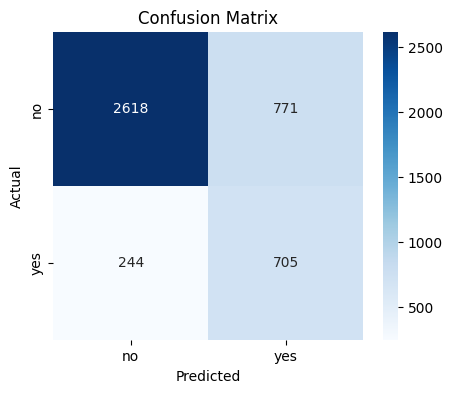

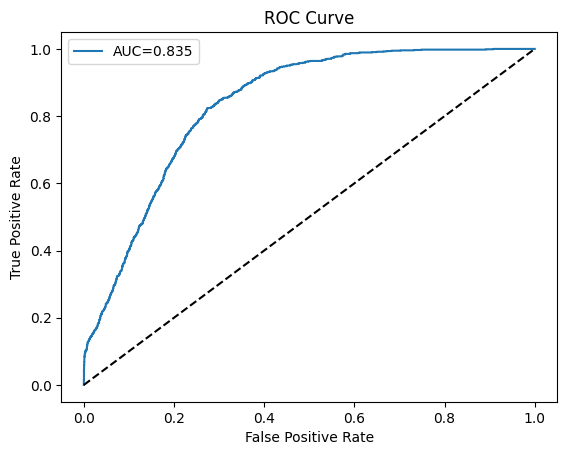

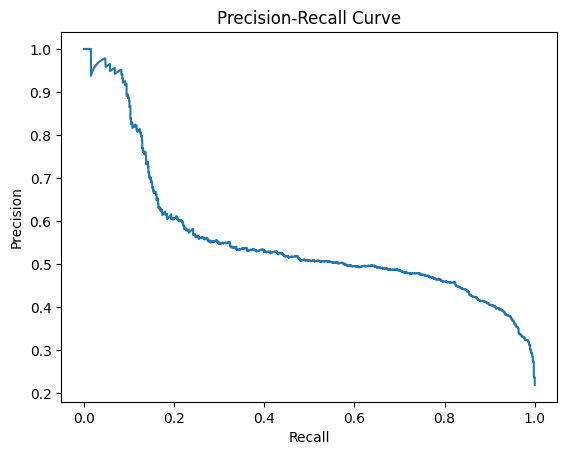

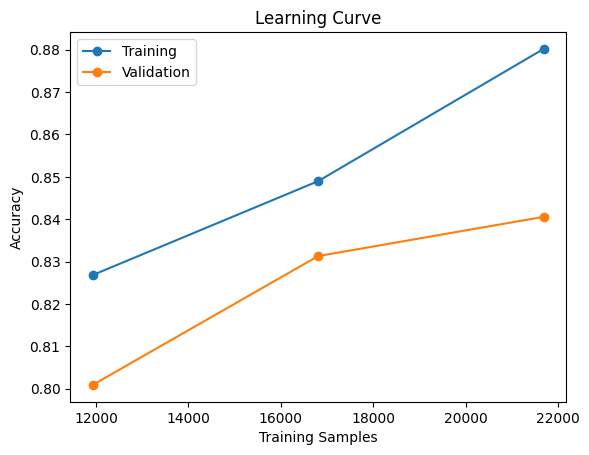

In [7]:
from sklearn.svm import LinearSVC

linear_svc = LinearSVC(
    C=0.1, # stronger regularization to simplify the model
    class_weight='balanced', # increase weight of minority class
    dual=False, # to directly search for answers, without comparing by default              
    max_iter=10000,  # ensure model has sufficient time to look for more weights        
    random_state=42 # ensure results are producible
)

linear_svc.fit(X_train, y_train)

evaluate_model(linear_svc, X_train, y_train, X_test, y_test)

Linear SVC Hyperparameter Tuning

In [8]:
from sklearn.svm import LinearSVC

# 1. Setup Model
svc = LinearSVC(max_iter=5000, dual='auto', random_state=42)

# 2. Grid focusing on Regularization
param_grid = {
    'C': [0.01, 0.1, 0.5, 0.8, 1.0],  # Checking lower values to find a simpler model
    'loss': ['hinge', 'squared_hinge'] # hinge ignores small errors, while squared_hinge is stricter
}

# 3. Run Tuning
print("Starting Linear SVC Tuning...")
grid_svc = GridSearchCV(svc, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1) # verbose = 1 to print updates occassionally
grid_svc.fit(X_train, y_train)

# 4. Evaluate Best Model
best_svc = grid_svc.best_estimator_
y_pred = best_svc.predict(X_test)

print("\n=== LINEAR SVC (TUNED) PERFORMANCE ===")
print(f"Best Params: {grid_svc.best_params_}")
print("-" * 30)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, pos_label='yes'):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred, pos_label='yes'):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred, pos_label='yes'):.4f}")

Starting Linear SVC Tuning...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

=== LINEAR SVC (TUNED) PERFORMANCE ===
Best Params: {'C': 0.01, 'loss': 'hinge'}
------------------------------
Accuracy : 0.5634
Precision: 0.3251
Recall   : 0.9252
F1 Score : 0.4811


SGD Classifier


=== MODEL PERFORMANCE ===
Accuracy : 0.7586
Precision: 0.4695
Recall   : 0.7945
F1 Score : 0.5902

Confusion Matrix Breakdown:
TN: 2537
FP: 852
FN: 195
TP: 754


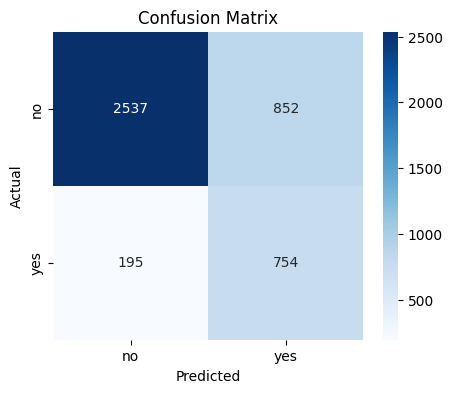

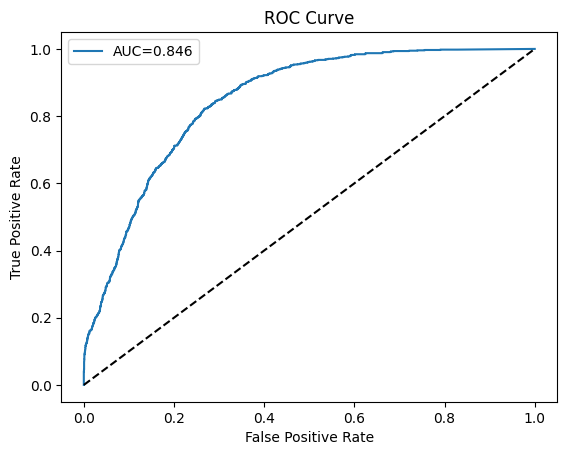

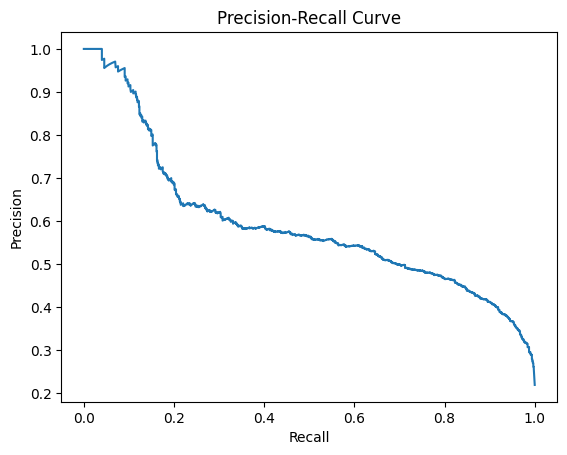

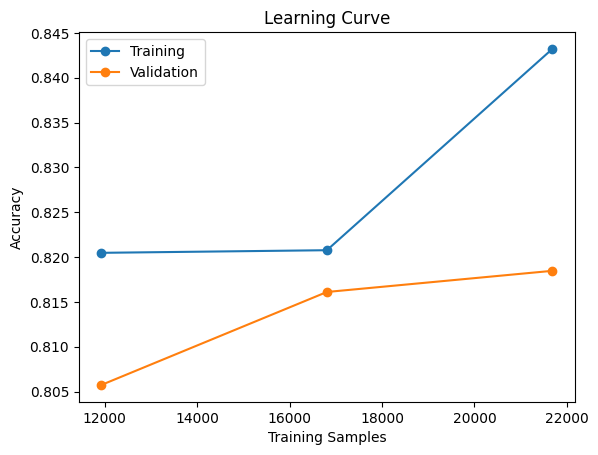

In [9]:
from sklearn.linear_model import SGDClassifier

sgd_model = SGDClassifier(
    loss='modified_huber',   # handles probabilities better & supports outliers
    penalty='l2',            # standard regularization (reduce model complexity)
    alpha=0.001,             # Regularization strength 
    max_iter=1000,
    tol=1e-3,                # stop if the model improves by less than this amount
    class_weight='balanced', 
    random_state=42,
    n_jobs=-1                
)

sgd_model.fit(X_train, y_train)

evaluate_model(sgd_model, X_train, y_train, X_test, y_test)

SGD Classifier Hyperparameter Tuning

In [10]:
from sklearn.linear_model import SGDClassifier

# 1. Setup Model
sgd = SGDClassifier(max_iter=2000, random_state=42, early_stopping=True)

# 2. Grid for Alpha (Regularization)
param_grid = {
    'loss': ['log_loss', 'hinge', 'modified_huber'], # Test different loss for optimizing for probability
    'alpha': [0.0001, 0.001, 0.01],                  # 0.0001 is standard, 0.01 is stricter
    'penalty': ['l2', 'l1']
}

# 3. Run Tuning
print("Starting SGD Classifier Tuning...")
grid_sgd = GridSearchCV(sgd, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid_sgd.fit(X_train, y_train)

# 4. Evaluate Best Model
best_sgd = grid_sgd.best_estimator_
y_pred = best_sgd.predict(X_test)

print("\n=== SGD CLASSIFIER (TUNED) PERFORMANCE ===")
print(f"Best Params: {grid_sgd.best_params_}")
print("-" * 30)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, pos_label='yes'):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred, pos_label='yes'):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred, pos_label='yes'):.4f}")

Starting SGD Classifier Tuning...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

=== SGD CLASSIFIER (TUNED) PERFORMANCE ===
Best Params: {'alpha': 0.0001, 'loss': 'log_loss', 'penalty': 'l2'}
------------------------------
Accuracy : 0.7490
Precision: 0.4579
Recall   : 0.8030
F1 Score : 0.5832


### Model Performance Comparison

**1. Base Model Comparison (Manual)**
| Model | Accuracy | Precision | Recall | F1 Score |
| :--- | :--- | :--- | :--- | :--- |
| **Logistic Regression** | **0.7676** | **0.4795** | **0.7271** | **0.5779** |
| Random Forest | 0.7545 | 0.4450 | 0.4942 | 0.4683 |
| Linear SVC | 0.7660 | 0.4776 | 0.7429 | 0.5814 |
| SGD Classifier | 0.7586 | 0.4695 | 0.7945 | 0.5902 |

**2. Hyperparameter Tuned Comparison**
| Model | Accuracy | Precision | Recall | F1 Score |
| :--- | :--- | :--- | :--- | :--- |
| **Logistic Regression** | **0.7561** | **0.4662** | **0.7924** | **0.5870** |
| Random Forest | 0.7545 | 0.4403 | 0.5437 | 0.4866 |
| Linear SVC | 0.5634 | 0.3251 | 0.9252 | 0.4811 |
| SGD Classifier | 0.7490 | 0.4579 | 0.8030 | 0.5832 |

**Feature Importance - Logistic Regression Hyperparameter Tuned**

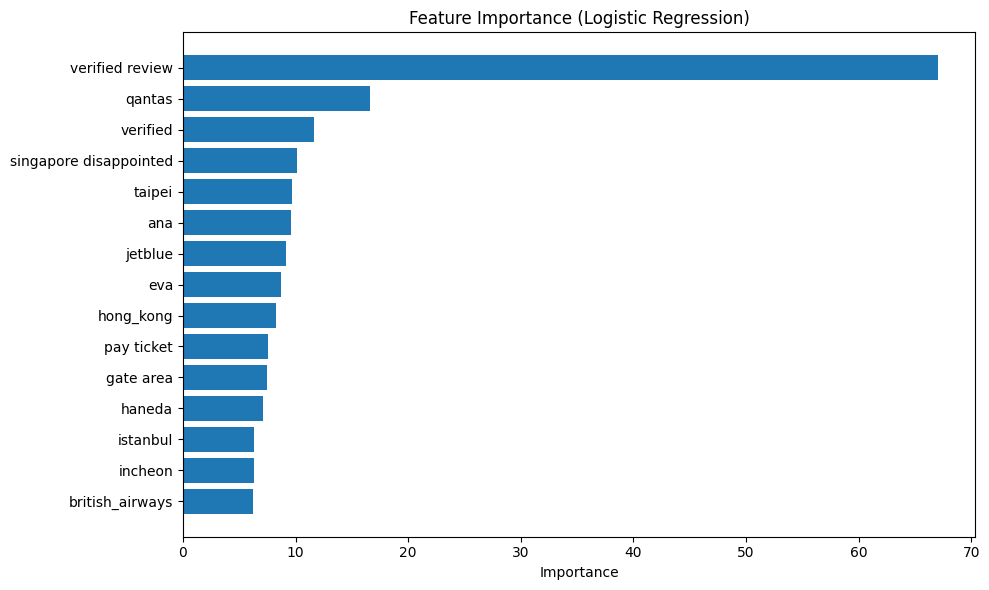

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# getting the model (Logistic Regression Hyperparameter Tuned)
best_model = grid_log.best_estimator_ 
feature_names = tfidf.get_feature_names_out()
coefficients = best_model.coef_[0]

# calculate the minimum length to make them fit
limit = min(len(feature_names), len(coefficients))

# trim both lists to the same size 
feature_names_fixed = feature_names[:limit]
coefficients_fixed = coefficients[:limit]

# plot
df_importance = pd.DataFrame({
    'Feature': feature_names_fixed,
    'Importance': np.abs(coefficients_fixed)
})

# sort top 15
df_sorted = df_importance.sort_values(by='Importance', ascending=True).tail(15)

# generating plot
plt.figure(figsize=(10, 6))
plt.barh(df_sorted['Feature'], df_sorted['Importance'], color='#1f77b4')
plt.title('Feature Importance (Logistic Regression)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

**Exporting Model for Webpage**

In [12]:
import pickle

final_model = best_log # Logistic Regression Hyperparameter Tuned

# Save vectorizer (TF-IDF) pickle file
with open('tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# Save model
with open('sentiment_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

print("Files exported")


Files exported
